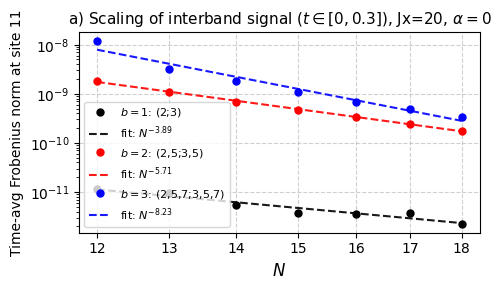

In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# -----------------------------
# Helper: load Mathematica-style table
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            row = []
            for e in line.split(","):
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
N_values = np.array([12, 13, 14, 15, 16, 17, 18])
fit_range = (12, 18)   # <-- fit ONLY in this range
base_path = "src"
site_of_interest = 10

tInterval = 0.01
steps_per_unit = 1 / tInterval
t_max = 0.3

prefixes = ["Winterb1Jx20a0N", "Winterb2Jx20a0N", "Winterb3Jx20a0N"]
labels   = [r"$b=1$: (2;3)", r"$b=2$: (2,5;3,5)", r"$b=3$: (2,5,7;3,5,7)"]
colors   = ["black", "red", "blue"]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 3))

for prefix, lab, col in zip(prefixes, labels, colors):
    x_list, y_list = [], []

    for N in N_values:
        fname = os.path.join(base_path, f"{prefix}{N}.txt")
        if not os.path.exists(fname):
            print(f"[WARN] Missing {fname}")
            continue

        raw = load_mathematica_data(fname)
        if raw.size == 0:
            print(f"[WARN] Empty {fname}")
            continue

        ti_max = min(int(t_max * steps_per_unit), raw.shape[0])
        y_mean = np.mean(raw[:ti_max, site_of_interest])

        if y_mean > 0:
            x_list.append(float(N))
            y_list.append(float(y_mean))

    x = np.array(x_list)
    y = np.array(y_list)

    # plot measured points
    ax.loglog(x, y, "o", color=col, markersize=5, label=lab)


    # -----------------------------
    # Fit ONLY N=13..18 (measured)
    # -----------------------------
    fit_mask = (x >= fit_range[0]) & (x <= fit_range[1])
    x_fit_pts = x[fit_mask]
    y_fit_pts = y[fit_mask]

    if len(x_fit_pts) >= 2:
        alpha, intercept = np.polyfit(np.log(x_fit_pts), np.log(y_fit_pts), 1)
        A = np.exp(intercept)

        x_fit = np.geomspace(x_fit_pts.min(), x_fit_pts.max(), 200)
        y_fit = A * x_fit**alpha

        ax.loglog(
            x_fit, y_fit,
            "--",
            color=col,
            linewidth=1.5,
            alpha=0.9,
            label=rf"fit: $N^{{{alpha:.2f}}}$"
        )

# -----------------------------
# Formatting
# -----------------------------
ax.set_xlabel(r"$N$", fontsize=12)
ax.set_ylabel(rf"Time-avg Frobenius norm at site {site_of_interest+1}", fontsize=10)
ax.grid(True, which="major", linestyle="--", alpha=0.6)
ax.set_title(
    rf"a) Scaling of interband signal ($t\in[0,{t_max}]$), Jx=20, $\alpha=0$",
    fontsize=11
)

ax.set_xticks([12, 13, 14, 15, 16, 17, 18])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

ax.legend(fontsize=8, loc="best")
fig.tight_layout()
plt.savefig("plt/WinterScalinga0Jx20.svg")
plt.show()


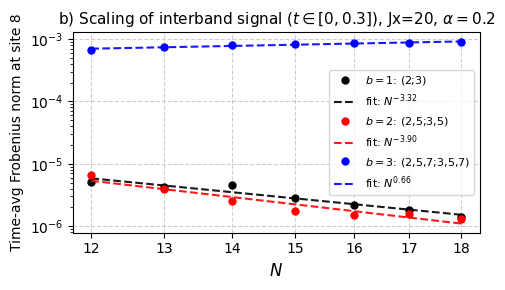

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# -----------------------------
# Helper: load Mathematica-style table
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            row = []
            for e in line.split(","):
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
N_values = np.array([12, 13, 14, 15, 16, 17, 18])
fit_range = (12, 18)   # <-- fit ONLY in this range
base_path = "src"
site_of_interest = 7

tInterval = 0.01
steps_per_unit = 1 / tInterval
t_max = 0.3

prefixes = ["Winterb1Jx20a02N", "Winterb2Jx20a02N", "Winterb3Jx20a02N"]
labels   = [r"$b=1$: (2;3)", r"$b=2$: (2,5;3,5)", r"$b=3$: (2,5,7;3,5,7)"]
colors   = ["black", "red", "blue"]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 3))

for prefix, lab, col in zip(prefixes, labels, colors):
    x_list, y_list = [], []

    for N in N_values:
        fname = os.path.join(base_path, f"{prefix}{N}.txt")
        if not os.path.exists(fname):
            print(f"[WARN] Missing {fname}")
            continue

        raw = load_mathematica_data(fname)
        if raw.size == 0:
            print(f"[WARN] Empty {fname}")
            continue

        ti_max = min(int(t_max * steps_per_unit), raw.shape[0])
        y_mean = np.mean(raw[:ti_max, site_of_interest])

        if y_mean > 0:
            x_list.append(float(N))
            y_list.append(float(y_mean))

    x = np.array(x_list)
    y = np.array(y_list)

    # plot measured points
    ax.loglog(x, y, "o", color=col, markersize=5, label=lab)

    # -----------------------------
    # Fit ONLY N=13..18 (measured)
    # -----------------------------
    fit_mask = (x >= fit_range[0]) & (x <= fit_range[1])
    x_fit_pts = x[fit_mask]
    y_fit_pts = y[fit_mask]

    if len(x_fit_pts) >= 2:
        alpha, intercept = np.polyfit(np.log(x_fit_pts), np.log(y_fit_pts), 1)
        A = np.exp(intercept)

        x_fit = np.geomspace(x_fit_pts.min(), x_fit_pts.max(), 200)
        y_fit = A * x_fit**alpha

        ax.loglog(
            x_fit, y_fit,
            "--",
            color=col,
            linewidth=1.5,
            alpha=0.9,
            label=rf"fit: $N^{{{alpha:.2f}}}$"
        )

# -----------------------------
# Formatting
# -----------------------------
ax.set_xlabel(r"$N$", fontsize=12)
ax.set_ylabel(rf"Time-avg Frobenius norm at site {site_of_interest+1}", fontsize=10)
ax.grid(True, which="major", linestyle="--", alpha=0.6)
ax.set_title(
    rf"b) Scaling of interband signal ($t\in[0,{t_max}]$), Jx=20, $\alpha=0.2$",
    fontsize=11
)

ax.set_xticks([12, 13, 14, 15, 16, 17, 18])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

ax.legend(fontsize=8, loc="best")
fig.tight_layout()
plt.savefig("plt/WinterScalinga02Jx20.svg")
plt.show()


[WARN] Empty src\Winterb3Jx20a05N18.txt


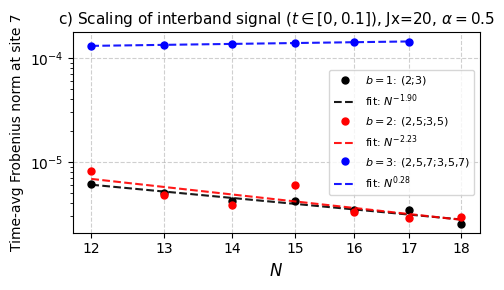

In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# -----------------------------
# Helper: load Mathematica-style table
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            row = []
            for e in line.split(","):
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
N_values = np.array([12, 13, 14, 15, 16, 17, 18])
fit_range = (12, 18)   # <-- fit ONLY in this range
base_path = "src"
site_of_interest = 6

tInterval = 0.01
steps_per_unit = 1 / tInterval
t_max = 0.1

prefixes = ["Winterb1Jx20a05N", "Winterb2Jx20a05N", "Winterb3Jx20a05N"]
labels   = [r"$b=1$: (2;3)", r"$b=2$: (2,5;3,5)", r"$b=3$: (2,5,7;3,5,7)"]
colors   = ["black", "red", "blue"]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 3))

for prefix, lab, col in zip(prefixes, labels, colors):
    x_list, y_list = [], []

    for N in N_values:
        fname = os.path.join(base_path, f"{prefix}{N}.txt")
        if not os.path.exists(fname):
            print(f"[WARN] Missing {fname}")
            continue

        raw = load_mathematica_data(fname)
        if raw.size == 0:
            print(f"[WARN] Empty {fname}")
            continue

        ti_max = min(int(t_max * steps_per_unit), raw.shape[0])
        y_mean = np.mean(raw[:ti_max, site_of_interest])

        if y_mean > 0:
            x_list.append(float(N))
            y_list.append(float(y_mean))

    x = np.array(x_list)
    y = np.array(y_list)

    # plot measured points
    ax.loglog(x, y, "o", color=col, markersize=5, label=lab)

    # -----------------------------
    # Fit ONLY N=13..18 (measured)
    # -----------------------------
    fit_mask = (x >= fit_range[0]) & (x <= fit_range[1])
    x_fit_pts = x[fit_mask]
    y_fit_pts = y[fit_mask]

    if len(x_fit_pts) >= 2:
        alpha, intercept = np.polyfit(np.log(x_fit_pts), np.log(y_fit_pts), 1)
        A = np.exp(intercept)

        x_fit = np.geomspace(x_fit_pts.min(), x_fit_pts.max(), 200)
        y_fit = A * x_fit**alpha

        ax.loglog(
            x_fit, y_fit,
            "--",
            color=col,
            linewidth=1.5,
            alpha=0.9,
            label=rf"fit: $N^{{{alpha:.2f}}}$"
        )

# -----------------------------
# Formatting
# -----------------------------
ax.set_xlabel(r"$N$", fontsize=12)
ax.set_ylabel(rf"Time-avg Frobenius norm at site {site_of_interest+1}", fontsize=10)
ax.grid(True, which="major", linestyle="--", alpha=0.6)
ax.set_title(
    rf"c) Scaling of interband signal ($t\in[0,{t_max}]$), Jx=20, $\alpha=0.5$",
    fontsize=11
)

ax.set_xticks([12, 13, 14, 15, 16, 17, 18])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

ax.legend(fontsize=8, loc="best")
fig.tight_layout()
plt.savefig("plt/WinterScalinga05Jx20.svg")
plt.show()


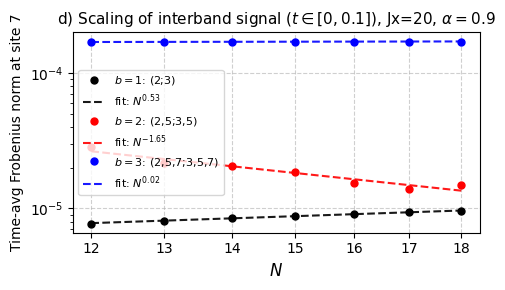

In [6]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# -----------------------------
# Helper: load Mathematica-style table
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            row = []
            for e in line.split(","):
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
N_values = np.array([12, 13, 14, 15, 16, 17, 18])
fit_range = (12, 18)   # <-- fit ONLY in this range
base_path = "src"
site_of_interest = 6

tInterval = 0.01
steps_per_unit = 1 / tInterval
t_max = 0.1

prefixes = ["Winterb1Jx20a09N", "Winterb2Jx20a09N", "Winterb3Jx20a09N"]
labels   = [r"$b=1$: (2;3)", r"$b=2$: (2,5;3,5)", r"$b=3$: (2,5,7;3,5,7)"]
colors   = ["black", "red", "blue"]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 3))

for prefix, lab, col in zip(prefixes, labels, colors):
    x_list, y_list = [], []

    for N in N_values:
        fname = os.path.join(base_path, f"{prefix}{N}.txt")
        if not os.path.exists(fname):
            print(f"[WARN] Missing {fname}")
            continue

        raw = load_mathematica_data(fname)
        if raw.size == 0:
            print(f"[WARN] Empty {fname}")
            continue

        ti_max = min(int(t_max * steps_per_unit), raw.shape[0])
        y_mean = np.mean(raw[:ti_max, site_of_interest])

        if y_mean > 0:
            x_list.append(float(N))
            y_list.append(float(y_mean))

    x = np.array(x_list)
    y = np.array(y_list)

    # plot measured points
    ax.loglog(x, y, "o", color=col, markersize=5, label=lab)

    # -----------------------------
    # Fit ONLY N=13..18 (measured)
    # -----------------------------
    fit_mask = (x >= fit_range[0]) & (x <= fit_range[1])
    x_fit_pts = x[fit_mask]
    y_fit_pts = y[fit_mask]

    if len(x_fit_pts) >= 2:
        alpha, intercept = np.polyfit(np.log(x_fit_pts), np.log(y_fit_pts), 1)
        A = np.exp(intercept)

        x_fit = np.geomspace(x_fit_pts.min(), x_fit_pts.max(), 200)
        y_fit = A * x_fit**alpha

        ax.loglog(
            x_fit, y_fit,
            "--",
            color=col,
            linewidth=1.5,
            alpha=0.9,
            label=rf"fit: $N^{{{alpha:.2f}}}$"
        )

# -----------------------------
# Formatting
# -----------------------------
ax.set_xlabel(r"$N$", fontsize=12)
ax.set_ylabel(rf"Time-avg Frobenius norm at site {site_of_interest+1}", fontsize=10)
ax.grid(True, which="major", linestyle="--", alpha=0.6)
ax.set_title(
    rf"d) Scaling of interband signal ($t\in[0,{t_max}]$), Jx=20, $\alpha=0.9$",
    fontsize=11
)

ax.set_xticks([12, 13, 14, 15, 16, 17, 18])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

ax.legend(fontsize=8, loc="best")
fig.tight_layout()
plt.savefig("plt/WinterScalinga09Jx20.svg")
plt.show()


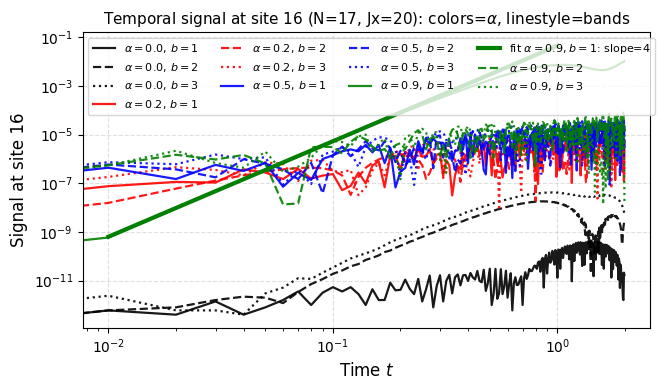


Fit result (alpha=0.9, band=1):
  log10(y) = 3.923455 log10(t) + -1.347757
  y ≈ 4.490e-02 * t^3.923


In [5]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt

# -----------------------------
# Helper: load Mathematica-style table
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            row = []
            for e in line.split(","):
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Parse alpha and band index from prefix
# -----------------------------
def parse_prefix(prefix):
    m_b = re.search(r"Winterb(\d+)", prefix)
    b = int(m_b.group(1)) if m_b else None

    m_a = re.search(r"a(\d+)", prefix)
    a_tok = m_a.group(1) if m_a else None

    alpha_map = {"0": 0.0, "02": 0.2, "05": 0.5, "09": 0.9}
    alpha = alpha_map.get(a_tok, None)

    return b, a_tok, alpha

# -----------------------------
# Settings
# -----------------------------
base_path = "src"
N = 17
site = 15
tInterval = 0.01
t_max = None

prefixes = [
    "Winterb1Jx20a0N",  "Winterb2Jx20a0N",  "Winterb3Jx20a0N",
    "Winterb1Jx20a02N", "Winterb2Jx20a02N", "Winterb3Jx20a02N",
    "Winterb1Jx20a05N", "Winterb2Jx20a05N", "Winterb3Jx20a05N",
    "Winterb1Jx20a09N", "Winterb2Jx20a09N", "Winterb3Jx20a09N",
]

alpha_to_color = {0.0: "black", 0.2: "red", 0.5: "blue", 0.9: "green"}
band_to_ls = {1: "-", 2: "--", 3: ":"}

# -----------------------------
# Fit settings (alpha=0.9, band=1)
# -----------------------------
fit_alpha = 0.9
fit_band = 1
t_lo, t_hi = 1e-2, 2e-1
t_extend_hi = 1e0

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 4))

fit_done = False
fit_params = None

for prefix in prefixes:
    b, a_tok, alpha = parse_prefix(prefix)

    fname = os.path.join(base_path, f"{prefix}{N}.txt")
    if not os.path.exists(fname):
        print(f"[WARN] Missing file: {fname} (skipping)")
        continue

    raw = load_mathematica_data(fname)
    if raw.size == 0:
        print(f"[WARN] Empty/failed load: {fname} (skipping)")
        continue

    if site >= raw.shape[1]:
        raise IndexError(f"site={site} out of bounds for {fname}")

    y = raw[:, site]
    t = np.arange(len(y)) * tInterval

    if t_max is not None:
        m = t <= t_max
        t = t[m]
        y = y[m]

    col = alpha_to_color.get(alpha, "gray")
    ls = band_to_ls.get(b, "-")

    label = rf"$\alpha={alpha},\, b={b}$"
    ax.loglog(t, y, linestyle=ls, color=col, linewidth=1.6, alpha=0.9, label=label)

    # -----------------------------
    # Fit ONLY alpha=0.9, band=1
    # -----------------------------
    if (not fit_done) and (alpha == fit_alpha) and (b == fit_band):
        mask = (t >= t_lo) & (t <= t_hi) & (y > 0)
        if np.count_nonzero(mask) >= 3:
            x = np.log10(t[mask])
            z = np.log10(y[mask])
            m_slope, c_int = np.polyfit(x, z, 1)
            fit_params = (m_slope, c_int)
            fit_done = True

            # extend fit to t = 10^0
            t_fit = np.logspace(np.log10(t_lo), np.log10(t_extend_hi), 300)
            y_fit = 10 ** (c_int + m_slope * np.log10(t_fit))

            ax.loglog(
                t_fit, y_fit,
                color=alpha_to_color[fit_alpha],
                linewidth=3.0,
                linestyle="-",
                label=rf"fit $\alpha=0.9, b=1$: slope={m_slope:.0f}"
            )

# -----------------------------
# Styling
# -----------------------------
ax.set_xlabel(r"Time $t$", fontsize=12)
ax.set_ylabel(rf"Signal at site {site+1}", fontsize=12)
ax.set_title(
    rf"Temporal signal at site {site+1} (N={N}, Jx=20): colors=$\alpha$, linestyle=bands",
    fontsize=11
)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(ncols=4, fontsize=8, loc="upper left", frameon=True)

fig.tight_layout()
plt.savefig(f"plt/Temporal_site{site}_N{N}_Jx20_fit_alpha09_band1.svg")
plt.show()

# -----------------------------
# Print fit result
# -----------------------------
if fit_params is not None:
    m_slope, c_int = fit_params
    print("\nFit result (alpha=0.9, band=1):")
    print(f"  log10(y) = {m_slope:.6f} log10(t) + {c_int:.6f}")
    print(f"  y ≈ {10**c_int:.3e} * t^{m_slope:.3f}")
else:
    print("\n[WARN] Fit not performed (insufficient data or missing curve).")

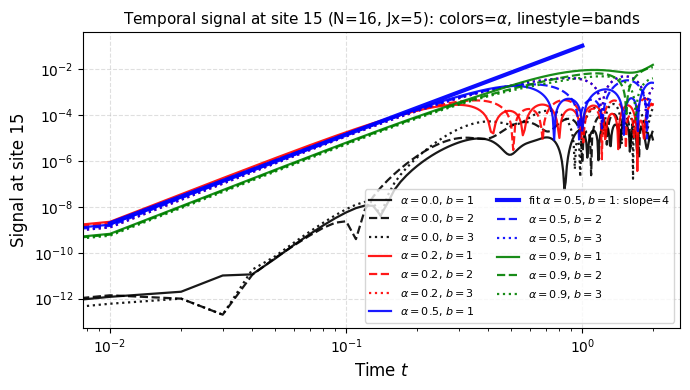


Fit result for alpha=0.5, band=1 over t in [1e-2, 2e-1]:
  log10(y) = m log10(t) + c
  m (slope)     = 3.86880493
  c (intercept) = -0.98091066
  => y ≈ 10^-0.9809 * t^3.8688


In [5]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt

# -----------------------------
# Helper: load Mathematica-style table
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            row = []
            for e in line.split(","):
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Parse alpha and band index from prefix
# -----------------------------
def parse_prefix(prefix):
    m_b = re.search(r"Winterb(\d+)", prefix)
    b = int(m_b.group(1)) if m_b else None

    m_a = re.search(r"a(\d+)", prefix)
    a_tok = m_a.group(1) if m_a else None

    alpha_map = {"0": 0.0, "02": 0.2, "05": 0.5, "09": 0.9}
    alpha = alpha_map.get(a_tok, None)

    return b, a_tok, alpha

# -----------------------------
# Settings
# -----------------------------
base_path = "src"
N = 16
site = 14              # 0-based; site+1 appears in labels
tInterval = 0.01
t_max = None

prefixes = [
    "Winterb1a0N",  "Winterb2a0N",  "Winterb3a0N",
    "Winterb1a02N", "Winterb2a02N", "Winterb3a02N",
    "Winterb1a05N", "Winterb2a05N", "Winterb3a05N",
    "Winterb1a09N", "Winterb2a09N", "Winterb3a09N",
]

alpha_to_color = {0.0: "black", 0.2: "red", 0.5: "blue", 0.9: "green"}
band_to_ls = {1: "-", 2: "--", 3: ":"}

# -----------------------------
# Fit settings (ONLY alpha=0.5, band=1, t in [1e-2, 2e-1])
# then EXTEND the fitted slope line out to t=10^0
# -----------------------------
fit_alpha = 0.5
fit_band = 1
t_lo, t_hi = 1e-2, 2e-1
t_extend_hi = 1e0

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 4))

fit_done = False
fit_params = None  # (m, c) in log10 space

for prefix in prefixes:
    b, a_tok, alpha = parse_prefix(prefix)

    fname = os.path.join(base_path, f"{prefix}{N}.txt")
    if not os.path.exists(fname):
        print(f"[WARN] Missing file: {fname} (skipping)")
        continue

    raw = load_mathematica_data(fname)
    if raw.size == 0:
        print(f"[WARN] Empty/failed load: {fname} (skipping)")
        continue

    if site >= raw.shape[1]:
        raise IndexError(
            f"site={site} out of bounds for {fname} (num_sites={raw.shape[1]})"
        )

    y = raw[:, site]
    t = np.arange(len(y)) * tInterval

    if t_max is not None:
        msk = t <= t_max
        t = t[msk]
        y = y[msk]

    col = alpha_to_color.get(alpha, "gray")
    ls = band_to_ls.get(b, "-")

    a_lab = rf"$\alpha={alpha}$" if alpha is not None else rf"$\alpha={a_tok}$"
    label = rf"{a_lab}, $b={b}$"

    ax.loglog(t, y, linestyle=ls, color=col, linewidth=1.6, alpha=0.9, label=label)

    # -----------------------------
    # Fit ONLY for alpha=0.5 and band=1
    # log10(y) = m log10(t) + c over [t_lo, t_hi]
    # -----------------------------
    if (not fit_done) and (alpha == fit_alpha) and (b == fit_band):
        mask = (t >= t_lo) & (t <= t_hi) & np.isfinite(y) & (y > 0)
        if np.count_nonzero(mask) < 3:
            print(f"[WARN] Not enough points to fit for {prefix}{N} in [{t_lo},{t_hi}]")
        else:
            x = np.log10(t[mask])
            z = np.log10(y[mask])
            m_slope, c_int = np.polyfit(x, z, 1)
            fit_params = (m_slope, c_int)
            fit_done = True

            # plot the fitted line EXTENDED to t=10^0
            t_fit = np.logspace(np.log10(t_lo), np.log10(t_extend_hi), 300)
            y_fit = 10 ** (c_int + m_slope * np.log10(t_fit))

            ax.loglog(
                t_fit, y_fit,
                color=alpha_to_color[fit_alpha],
                linestyle="-",
                linewidth=3.0,
                alpha=0.95,
                label=rf"fit $\alpha=0.5, b=1$: slope={m_slope:.0f}"
            )

# -----------------------------
# Styling
# -----------------------------
ax.set_xlabel(r"Time $t$", fontsize=12)
ax.set_ylabel(rf"Signal at site {site+1}", fontsize=12)
ax.set_title(
    rf"Temporal signal at site {site+1} (N={N}, Jx=5): colors=$\alpha$, linestyle=bands",
    fontsize=11
)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(ncols=2, fontsize=8, loc="best", frameon=True)

fig.tight_layout()
os.makedirs("plt", exist_ok=True)
plt.savefig(f"plt/Temporal_site{site}_N{N}_Jx20.svg")
plt.show()

# -----------------------------
# Print fit result
# -----------------------------
if fit_params is None:
    print("\n[WARN] No fit performed (alpha=0.5, band=1 not found or insufficient points).")
else:
    m_slope, c_int = fit_params
    print("\nFit result for alpha=0.5, band=1 over t in [1e-2, 2e-1]:")
    print(f"  log10(y) = m log10(t) + c")
    print(f"  m (slope)     = {m_slope:.8f}")
    print(f"  c (intercept) = {c_int:.8f}")
    print(f"  => y ≈ 10^{c_int:.4f} * t^{m_slope:.4f}")

Shape: (200, 17)
Last 3 rows sample:
 [[2.75713785e-01 4.24034321e-01 9.75813719e-02 1.10014797e-01
  2.48335952e-02 1.11218029e-01 5.86704490e-02 1.36145253e-02
  1.89406282e-03 1.79320105e-04 1.24155628e-05 6.59265198e-07
  2.78113976e-08 1.02520215e-09 9.55902024e-11 1.59872116e-12
  1.88071780e-11]
 [2.78595985e-01 4.23359659e-01 9.26488422e-02 1.05660161e-01
  2.88372177e-02 1.10571628e-01 5.97640418e-02 1.40870352e-02
  1.98598446e-03 1.90329951e-04 1.33317444e-05 7.15728210e-07
  3.03740144e-08 8.74611494e-10 1.48991930e-10 2.12052598e-11
  7.81597009e-12]
 [2.81278681e-01 4.22279826e-01 8.74167542e-02 1.01204919e-01
  3.27880860e-02 1.09854156e-01 6.08543169e-02 1.45705830e-02
  2.08155522e-03 2.01930750e-04 1.43093262e-05 7.77108800e-07
  3.35384165e-08 1.29241062e-09 1.52211577e-10 1.72084569e-11
  1.73860926e-11]]


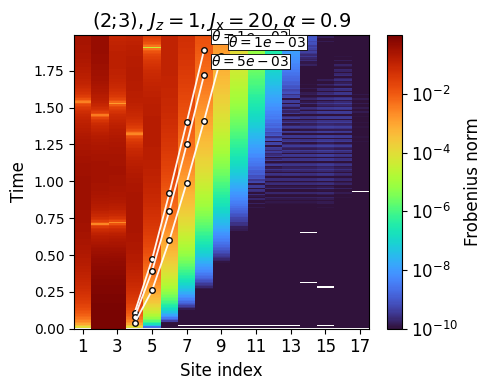

C:\Users\shrey\AppData\Local\Temp\ipykernel_2536\2450547337.py:191: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


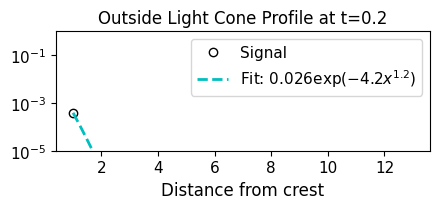

In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e")
            line = line.strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Load data
# -----------------------------
data_path = os.path.join("src", "Winterb1Jx20a0N17.txt")
raw_data = load_mathematica_data(data_path)

print("Shape:", raw_data.shape)
print("Last 3 rows sample:\n", raw_data[-3:])

# -----------------------------
# Time axis settings (FIX)
# -----------------------------
step_size = 0.01              # physical Δt per row
steps_per_unit = 1 / step_size

n_steps, n_sites = raw_data.shape
time_axis = np.arange(n_steps) / steps_per_unit
t_min, t_max = time_axis.min(), time_axis.max()

# -----------------------------
# Heatmap + iso-threshold arrival curves (with labels ON the curves)
# -----------------------------
plt.figure(figsize=(5, 4))
ax = plt.gca()

im = ax.imshow(
    raw_data,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    interpolation="none",
    norm=mcolors.LogNorm(vmin=1e-10, vmax=np.nanmax(raw_data)),
    extent=[0, n_sites, t_min, t_max]
)

# -----------------------------
# Overlay threshold arrival points + labels on top of the curves
# -----------------------------
thresholds = [1e-2, 5e-3, 1e-3]  # edit freely

# only consider sites strictly greater than 4 (0-based column index)
site_min = 3  # note: this corresponds to sites >= 4 in 1-based labeling
site_cols = np.arange(site_min, n_sites)  # 0-based column indices

# x positions to match your heatmap/ticks (pixel centers at +0.5)
x_plot = site_cols + 0.5

# label offsets (in data coords)
label_dx = 0.4
label_dy = 0.02 * (t_max - t_min)

for theta in thresholds:
    t_points = []
    x_points = []

    for j, xj in zip(site_cols, x_plot):
        col = raw_data[:, j]

        # indices where signal crosses threshold
        idx = np.where(col >= theta)[0]
        if idx.size == 0:
            continue  # never crosses -> skip this site

        # first crossing time (discrete)
        t0 = time_axis[idx[0]]
        x_points.append(xj)
        t_points.append(t0)

    if len(x_points) < 2:
        print(f"[WARN] Not enough points for theta={theta:.1e} to draw a line.")
        continue

    x_points = np.array(x_points)
    t_points = np.array(t_points)

    # sort by x so the connecting line is not scrambled
    order = np.argsort(x_points)
    x_points = x_points[order]
    t_points = t_points[order]

    # plot points + connecting line
    ax.plot(
        x_points, t_points,
        "wo-",              # white points + line
        markersize=4,
        markeredgecolor="k",
        linewidth=1.3,
        alpha=0.95,
        zorder=5
    )

    # label at the TOP (last point) of the curve
    xt, yt = x_points[-1], t_points[-1]
    ax.text(
        xt + label_dx,
        yt + label_dy,
        fr"$\theta={theta:.0e}$",
        fontsize=10,
        ha="left",
        va="bottom",
        color="k",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            linewidth=0.6,
            pad=0.15
        ),
        zorder=6
    )

# -----------------------------
# Colorbar (plain, no threshold decorations)
# -----------------------------
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Frobenius norm", fontsize=12)

# -----------------------------
# Axes formatting
# -----------------------------
ax.set_xlabel("Site index", fontsize=12)
ax.set_ylabel("Time", fontsize=12)
ax.set_title(r"(2;3), $J_z=1, J_{\mathrm{x}}=20, \alpha=0.9$", fontsize=14)

# Fix site index ticks at centers
step = 2
positions = np.arange(0.5, n_sites, step)
labels = np.arange(1, n_sites + 1, step)
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=12)

plt.tight_layout()
os.makedirs("plt", exist_ok=True)
plt.savefig("plt/Winterb1Jx20a09N_threshold_labels.svg", bbox_inches="tight")
plt.show()

# -----------------------------
# Outside light-cone profile fit (your existing block)
# -----------------------------
time = 0.2
t_index = int(time * steps_per_unit)

if t_index < 0 or t_index >= n_steps:
    raise ValueError(f"time={time} gives t_index={t_index}, but n_steps={n_steps}. Check step_size.")

profile = raw_data[t_index, 4:]
sites = np.arange(1, profile.size + 1)

n_fit = 3
x_fit_points = sites[:n_fit]
y_fit_points = profile[:n_fit]

mask = y_fit_points > 1e-14
x_fit_points = x_fit_points[mask]
y_fit_points = y_fit_points[mask]

def log_model(x, logA, a, p):
    return logA - a * (x**p)

logy = np.log(y_fit_points)
popt, _ = curve_fit(
    log_model, x_fit_points, logy,
    p0=(np.log(y_fit_points.max()), 0.01, 2.0)
)
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

x_dense = np.linspace(sites.min(), sites.max(), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense**p_fit)

plt.figure(figsize=(4.5, 2.2))
plt.semilogy(sites, profile, 'wo', markersize=6,
             markeredgecolor="k", label="Signal")
plt.semilogy(x_dense, y_dense, 'c--', linewidth=2,
             label=fr"Fit: ${A_fit:.2g}\exp(-{a_fit:.2g} x^{{{p_fit:.2g}}})$")

plt.xlabel("Distance from crest", fontsize=12)
plt.title(f"Outside Light Cone Profile at t={time}", fontsize=12)
plt.ylim(1e-5, 1)
plt.legend(fontsize=11, loc="upper right")
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig("plt/Winterb1Jx20a09NOutLC.svg", bbox_inches="tight")
plt.show()

Shape: (200, 12)
Last 3 rows sample:
 [[2.75710534e-01 4.24031393e-01 9.75837506e-02 1.10010349e-01
  2.48344156e-02 1.11214189e-01 5.86686049e-02 1.36138912e-02
  1.89396719e-03 1.79328551e-04 1.23778434e-05 7.10452208e-07]
 [2.78593132e-01 4.23355879e-01 9.26514911e-02 1.05656206e-01
  2.88377262e-02 1.10567936e-01 5.97620332e-02 1.40864222e-02
  1.98587748e-03 1.90340672e-04 1.32904540e-05 7.72142417e-07]
 [2.81276123e-01 4.22275485e-01 8.74196109e-02 1.01201331e-01
  3.27883367e-02 1.09850570e-01 6.08521747e-02 1.45699835e-02
  2.08143705e-03 2.01943386e-04 1.42636326e-05 8.38694802e-07]]


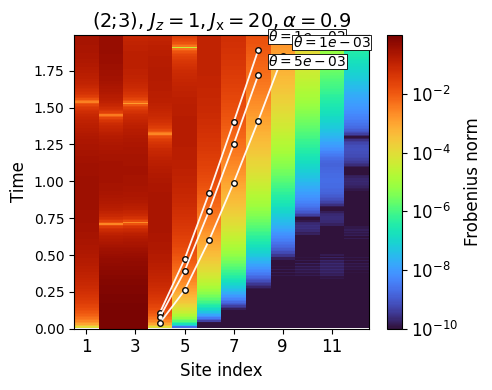

C:\Users\shrey\AppData\Local\Temp\ipykernel_2536\2846257684.py:191: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


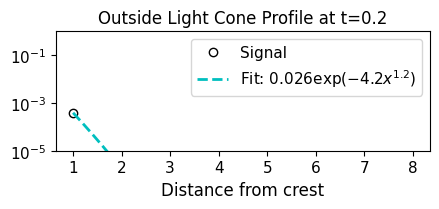

In [8]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e")
            line = line.strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Load data
# -----------------------------
data_path = os.path.join("src", "Winterb1Jx20a0N12.txt")
raw_data = load_mathematica_data(data_path)

print("Shape:", raw_data.shape)
print("Last 3 rows sample:\n", raw_data[-3:])

# -----------------------------
# Time axis settings (FIX)
# -----------------------------
step_size = 0.01              # physical Δt per row
steps_per_unit = 1 / step_size

n_steps, n_sites = raw_data.shape
time_axis = np.arange(n_steps) / steps_per_unit
t_min, t_max = time_axis.min(), time_axis.max()

# -----------------------------
# Heatmap + iso-threshold arrival curves (with labels ON the curves)
# -----------------------------
plt.figure(figsize=(5, 4))
ax = plt.gca()

im = ax.imshow(
    raw_data,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    interpolation="none",
    norm=mcolors.LogNorm(vmin=1e-10, vmax=np.nanmax(raw_data)),
    extent=[0, n_sites, t_min, t_max]
)

# -----------------------------
# Overlay threshold arrival points + labels on top of the curves
# -----------------------------
thresholds = [1e-2, 5e-3, 1e-3]  # edit freely

# only consider sites strictly greater than 4 (0-based column index)
site_min = 3  # note: this corresponds to sites >= 4 in 1-based labeling
site_cols = np.arange(site_min, n_sites)  # 0-based column indices

# x positions to match your heatmap/ticks (pixel centers at +0.5)
x_plot = site_cols + 0.5

# label offsets (in data coords)
label_dx = 0.4
label_dy = 0.02 * (t_max - t_min)

for theta in thresholds:
    t_points = []
    x_points = []

    for j, xj in zip(site_cols, x_plot):
        col = raw_data[:, j]

        # indices where signal crosses threshold
        idx = np.where(col >= theta)[0]
        if idx.size == 0:
            continue  # never crosses -> skip this site

        # first crossing time (discrete)
        t0 = time_axis[idx[0]]
        x_points.append(xj)
        t_points.append(t0)

    if len(x_points) < 2:
        print(f"[WARN] Not enough points for theta={theta:.1e} to draw a line.")
        continue

    x_points = np.array(x_points)
    t_points = np.array(t_points)

    # sort by x so the connecting line is not scrambled
    order = np.argsort(x_points)
    x_points = x_points[order]
    t_points = t_points[order]

    # plot points + connecting line
    ax.plot(
        x_points, t_points,
        "wo-",              # white points + line
        markersize=4,
        markeredgecolor="k",
        linewidth=1.3,
        alpha=0.95,
        zorder=5
    )

    # label at the TOP (last point) of the curve
    xt, yt = x_points[-1], t_points[-1]
    ax.text(
        xt + label_dx,
        yt + label_dy,
        fr"$\theta={theta:.0e}$",
        fontsize=10,
        ha="left",
        va="bottom",
        color="k",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            linewidth=0.6,
            pad=0.15
        ),
        zorder=6
    )

# -----------------------------
# Colorbar (plain, no threshold decorations)
# -----------------------------
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Frobenius norm", fontsize=12)

# -----------------------------
# Axes formatting
# -----------------------------
ax.set_xlabel("Site index", fontsize=12)
ax.set_ylabel("Time", fontsize=12)
ax.set_title(r"(2;3), $J_z=1, J_{\mathrm{x}}=20, \alpha=0.9$", fontsize=14)

# Fix site index ticks at centers
step = 2
positions = np.arange(0.5, n_sites, step)
labels = np.arange(1, n_sites + 1, step)
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=12)

plt.tight_layout()
os.makedirs("plt", exist_ok=True)
plt.savefig("plt/Winterb1Jx20a09N_threshold_labels.svg", bbox_inches="tight")
plt.show()

# -----------------------------
# Outside light-cone profile fit (your existing block)
# -----------------------------
time = 0.2
t_index = int(time * steps_per_unit)

if t_index < 0 or t_index >= n_steps:
    raise ValueError(f"time={time} gives t_index={t_index}, but n_steps={n_steps}. Check step_size.")

profile = raw_data[t_index, 4:]
sites = np.arange(1, profile.size + 1)

n_fit = 3
x_fit_points = sites[:n_fit]
y_fit_points = profile[:n_fit]

mask = y_fit_points > 1e-14
x_fit_points = x_fit_points[mask]
y_fit_points = y_fit_points[mask]

def log_model(x, logA, a, p):
    return logA - a * (x**p)

logy = np.log(y_fit_points)
popt, _ = curve_fit(
    log_model, x_fit_points, logy,
    p0=(np.log(y_fit_points.max()), 0.01, 2.0)
)
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

x_dense = np.linspace(sites.min(), sites.max(), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense**p_fit)

plt.figure(figsize=(4.5, 2.2))
plt.semilogy(sites, profile, 'wo', markersize=6,
             markeredgecolor="k", label="Signal")
plt.semilogy(x_dense, y_dense, 'c--', linewidth=2,
             label=fr"Fit: ${A_fit:.2g}\exp(-{a_fit:.2g} x^{{{p_fit:.2g}}})$")

plt.xlabel("Distance from crest", fontsize=12)
plt.title(f"Outside Light Cone Profile at t={time}", fontsize=12)
plt.ylim(1e-5, 1)
plt.legend(fontsize=11, loc="upper right")
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig("plt/Winterb1Jx20a09NOutLC.svg", bbox_inches="tight")
plt.show()

Shape: (200, 17)
Last 3 rows sample:
 [[0.22269379 0.20360042 0.1795238  0.05905107 0.05195752 0.08528193
  0.06215274 0.03418706 0.02294602 0.01612359 0.01338013 0.01211811
  0.01008078 0.0092988  0.00873297 0.00994629 0.00674899]
 [0.22636328 0.20459344 0.17627415 0.06189069 0.05148617 0.08525413
  0.06273355 0.03469182 0.02323399 0.0163493  0.01355604 0.0122748
  0.01020626 0.00942948 0.00891165 0.01021239 0.0069883 ]
 [0.22986347 0.20542089 0.17269997 0.06461807 0.05102945 0.08521693
  0.06331183 0.03518988 0.02351181 0.01656908 0.0137268  0.01242674
  0.01032854 0.00955975 0.0090965  0.01048187 0.00722999]]


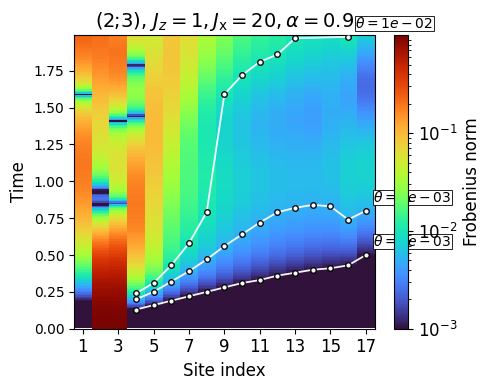

C:\Users\shrey\AppData\Local\Temp\ipykernel_8840\2095305269.py:191: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


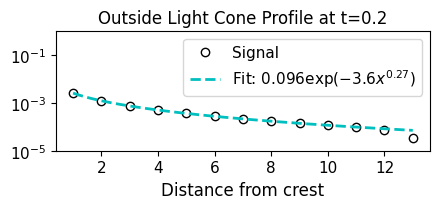

In [12]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e")
            line = line.strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Load data
# -----------------------------
data_path = os.path.join("src", "Winterb1Jx20a09N17.txt")
raw_data = load_mathematica_data(data_path)

print("Shape:", raw_data.shape)
print("Last 3 rows sample:\n", raw_data[-3:])

# -----------------------------
# Time axis settings (FIX)
# -----------------------------
step_size = 0.01              # physical Δt per row
steps_per_unit = 1 / step_size

n_steps, n_sites = raw_data.shape
time_axis = np.arange(n_steps) / steps_per_unit
t_min, t_max = time_axis.min(), time_axis.max()

# -----------------------------
# Heatmap + iso-threshold arrival curves (with labels ON the curves)
# -----------------------------
plt.figure(figsize=(5, 4))
ax = plt.gca()

im = ax.imshow(
    raw_data,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    interpolation="none",
    norm=mcolors.LogNorm(vmin=1e-3, vmax=np.nanmax(raw_data)),
    extent=[0, n_sites, t_min, t_max]
)

# -----------------------------
# Overlay threshold arrival points + labels on top of the curves
# -----------------------------
thresholds = [1e-2, 5e-3, 1e-3]  # edit freely

# only consider sites strictly greater than 4 (0-based column index)
site_min = 3  # note: this corresponds to sites >= 4 in 1-based labeling
site_cols = np.arange(site_min, n_sites)  # 0-based column indices

# x positions to match your heatmap/ticks (pixel centers at +0.5)
x_plot = site_cols + 0.5

# label offsets (in data coords)
label_dx = 0.4
label_dy = 0.02 * (t_max - t_min)

for theta in thresholds:
    t_points = []
    x_points = []

    for j, xj in zip(site_cols, x_plot):
        col = raw_data[:, j]

        # indices where signal crosses threshold
        idx = np.where(col >= theta)[0]
        if idx.size == 0:
            continue  # never crosses -> skip this site

        # first crossing time (discrete)
        t0 = time_axis[idx[0]]
        x_points.append(xj)
        t_points.append(t0)

    if len(x_points) < 2:
        print(f"[WARN] Not enough points for theta={theta:.1e} to draw a line.")
        continue

    x_points = np.array(x_points)
    t_points = np.array(t_points)

    # sort by x so the connecting line is not scrambled
    order = np.argsort(x_points)
    x_points = x_points[order]
    t_points = t_points[order]

    # plot points + connecting line
    ax.plot(
        x_points, t_points,
        "wo-",              # white points + line
        markersize=4,
        markeredgecolor="k",
        linewidth=1.3,
        alpha=0.95,
        zorder=5
    )

    # label at the TOP (last point) of the curve
    xt, yt = x_points[-1], t_points[-1]
    ax.text(
        xt + label_dx,
        yt + label_dy,
        fr"$\theta={theta:.0e}$",
        fontsize=10,
        ha="left",
        va="bottom",
        color="k",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            linewidth=0.6,
            pad=0.15
        ),
        zorder=6
    )

# -----------------------------
# Colorbar (plain, no threshold decorations)
# -----------------------------
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Frobenius norm", fontsize=12)

# -----------------------------
# Axes formatting
# -----------------------------
ax.set_xlabel("Site index", fontsize=12)
ax.set_ylabel("Time", fontsize=12)
ax.set_title(r"(2;3), $J_z=1, J_{\mathrm{x}}=20, \alpha=0.9$", fontsize=14)

# Fix site index ticks at centers
step = 2
positions = np.arange(0.5, n_sites, step)
labels = np.arange(1, n_sites + 1, step)
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=12)

plt.tight_layout()
os.makedirs("plt", exist_ok=True)
plt.savefig("plt/Winterb1Jx20a09N_threshold_labels.svg", bbox_inches="tight")
plt.show()

# -----------------------------
# Outside light-cone profile fit (your existing block)
# -----------------------------
time = 0.2
t_index = int(time * steps_per_unit)

if t_index < 0 or t_index >= n_steps:
    raise ValueError(f"time={time} gives t_index={t_index}, but n_steps={n_steps}. Check step_size.")

profile = raw_data[t_index, 4:]
sites = np.arange(1, profile.size + 1)

n_fit = 3
x_fit_points = sites[:n_fit]
y_fit_points = profile[:n_fit]

mask = y_fit_points > 1e-14
x_fit_points = x_fit_points[mask]
y_fit_points = y_fit_points[mask]

def log_model(x, logA, a, p):
    return logA - a * (x**p)

logy = np.log(y_fit_points)
popt, _ = curve_fit(
    log_model, x_fit_points, logy,
    p0=(np.log(y_fit_points.max()), 0.01, 2.0)
)
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

x_dense = np.linspace(sites.min(), sites.max(), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense**p_fit)

plt.figure(figsize=(4.5, 2.2))
plt.semilogy(sites, profile, 'wo', markersize=6,
             markeredgecolor="k", label="Signal")
plt.semilogy(x_dense, y_dense, 'c--', linewidth=2,
             label=fr"Fit: ${A_fit:.2g}\exp(-{a_fit:.2g} x^{{{p_fit:.2g}}})$")

plt.xlabel("Distance from crest", fontsize=12)
plt.title(f"Outside Light Cone Profile at t={time}", fontsize=12)
plt.ylim(1e-5, 1)
plt.legend(fontsize=11, loc="upper right")
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig("plt/Winterb1Jx20a09NOutLC.svg", bbox_inches="tight")
plt.show()

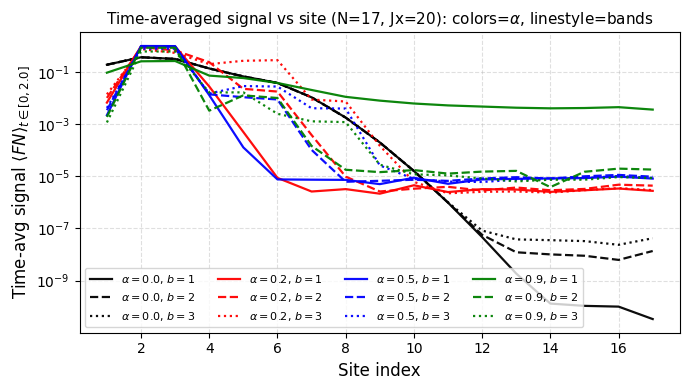

In [4]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt

# -----------------------------
# Helper: load Mathematica-style table
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            row = []
            for e in line.split(","):
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Parse alpha and band index from prefix
# -----------------------------
def parse_prefix(prefix):
    m_b = re.search(r"Winterb(\d+)", prefix)
    b = int(m_b.group(1)) if m_b else None

    m_a = re.search(r"a(\d+)", prefix)
    a_tok = m_a.group(1) if m_a else None  # "0", "02", "05", "09"

    alpha_map = {"0": 0.0, "02": 0.2, "05": 0.5, "09": 0.9}
    alpha = alpha_map.get(a_tok, None)

    return b, a_tok, alpha

# -----------------------------
# Settings
# -----------------------------
base_path = "src"
N = 17
tInterval = 0.01
t_max = 2.0          # set None to average over full time range
j_min = 0            # optionally restrict sites, e.g. 4
j_max = None         # optionally restrict sites, e.g. 20

prefixes = [
    "Winterb1Jx20a0N",  "Winterb2Jx20a0N",  "Winterb3Jx20a0N",
    "Winterb1Jx20a02N", "Winterb2Jx20a02N", "Winterb3Jx20a02N",
    "Winterb1Jx20a05N", "Winterb2Jx20a05N", "Winterb3Jx20a05N",
    "Winterb1Jx20a09N", "Winterb2Jx20a09N", "Winterb3Jx20a09N",
]

alpha_to_color = {0.0: "black", 0.2: "red", 0.5: "blue", 0.9: "green"}
band_to_ls = {1: "-", 2: "--", 3: ":"}

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 4))

for prefix in prefixes:
    b, a_tok, alpha = parse_prefix(prefix)

    fname = os.path.join(base_path, f"{prefix}{N}.txt")
    if not os.path.exists(fname):
        print(f"[WARN] Missing file: {fname} (skipping)")
        continue

    raw = load_mathematica_data(fname)
    if raw.size == 0:
        print(f"[WARN] Empty/failed load: {fname} (skipping)")
        continue

    n_steps, n_sites = raw.shape

    # time window indices for averaging
    if t_max is None:
        ti_max = n_steps
    else:
        ti_max = min(int(t_max / tInterval), n_steps)

    # site range
    jj0 = max(0, int(j_min))
    jj1 = n_sites if (j_max is None) else min(int(j_max), n_sites)
    j = np.arange(jj0, jj1)

    # time-averaged signal at each site j
    y_mean_vs_j = np.mean(raw[:ti_max, jj0:jj1], axis=0)

    col = alpha_to_color.get(alpha, "gray")
    ls = band_to_ls.get(b, "-")

    a_lab = rf"$\alpha={alpha}$" if alpha is not None else rf"$\alpha={a_tok}$"
    label = rf"{a_lab}, $b={b}$"

    # plot vs site index (use +1 if you want 1-based site labels)
    ax.semilogy(j + 1, y_mean_vs_j, linestyle=ls, color=col, linewidth=1.6, alpha=0.95, label=label)

ax.set_xlabel("Site index", fontsize=12)
ax.set_ylabel(rf"Time-avg signal $\langle FN \rangle_{{t\in[0,{t_max}]}}$", fontsize=12)
ax.set_title(rf"Time-averaged signal vs site (N={N}, Jx=20): colors=$\alpha$, linestyle=bands", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)

ax.legend(ncols=4, fontsize=8, loc="best", frameon=True)

fig.tight_layout()
os.makedirs("plt", exist_ok=True)
# plt.savefig(f"plt/TimeAvg_vs_site_N{N}_Jx20_multiAlpha_multiBand.svg")
plt.show()
